In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
import pandas as pd

# Corrected file path
file_path = '/content/TheraBank (3) (1) (2).xlsx'

if os.path.exists(file_path):
    df = pd.read_excel(file_path)
    display(df.head())
else:
    print(f"Error: The file '{file_path}' was not found. Please ensure it is uploaded to your Colab environment (e.g., using the file explorer icon on the left).")
    print("If you have just uploaded it, please try running this cell again.")

,ID,Age (in years),Experience (in years),Income (in K/month),Family members,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,4.0,1.6,1,0,0,1,0,0,0
1,2,45,19,34,3.0,1.5,1,0,0,1,0,0,0
2,3,39,15,11,1.0,1.0,1,0,0,0,0,0,0
3,4,35,9,100,1.0,2.7,2,0,0,0,0,0,0
4,5,35,8,45,4.0,1.0,2,0,0,0,0,0,1


In [ ]:
#set visualization
sns.set_theme(style ="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14
})
print("Environment setup complete! Ready to load data.")

Environment setup complete! Ready to load data.


In [ ]:
import pandas as pd

# check and drop duplicate customer IDs if any
dupes = df['ID'].duplicated().sum()
print(f"[+] Duplicate customer IDs: {dupes}")
if dupes > 0:
  df = df.drop_duplicates(subset=['ID'], keep='first')
  print("dropped duplicates")

# 2. Correct negative Experience values (replace with 0 as entry-level)
negative_exp = (df['Experience (in years)'] < 0).sum()
print(f"[+] Found {negative_exp} rows with negative Experience values.")
if negative_exp > 0:
    df['Experience (in years)'] = df['Experience (in years)'].clip(lower=0)
    print("Fixed! All negative experiences set to 0.")

# 3. Check for missing values before processing
print("\n--- MISSING VALUES BEFORE CLEANING ---")
print(df.isnull().sum())

# 4. Handle missing values in 'Family members' as a separate class "Missing"
df['Family members'] = df['Family members'].astype(str)
df['Family members'] = df['Family members'].replace('nan', 'Missing')

print("\n--- VERIFICATION: NEW FAMILY MEMBERS DISTRIBUTION ---")
print(df['Family members'].value_counts(dropna=False))

[+] Duplicate customer IDs: 0
[+] Found 52 rows with negative Experience values.
Fixed! All negative experiences set to 0.

--- MISSING VALUES BEFORE CLEANING ---
ID                        0
Age (in years)            0
Experience (in years)     0
Income (in K/month)       0
Family members           18
CCAvg                     0
Education                 0
Mortgage                  0
Personal Loan             0
Securities Account        0
CD Account                0
Online                    0
CreditCard                0
dtype: int64

--- VERIFICATION: NEW FAMILY MEMBERS DISTRIBUTION ---
Family members
1.0        1464
2.0        1292
4.0        1217
3.0        1009
Missing      18
Name: count, dtype: int64


In [ ]:
numeric_cols

NameError: name 'numeric_cols' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ID                     5000 non-null   int64   
 1   Age (in years)         5000 non-null   int64   
 2   Experience (in years)  5000 non-null   int64   
 3   Income (in K/month)    5000 non-null   int64   
 4   Family members         5000 non-null   object  
 5   CCAvg                  5000 non-null   float64 
 6   Education              5000 non-null   category
 7   Mortgage               5000 non-null   int64   
 8   Personal Loan          5000 non-null   category
 9   Securities Account     5000 non-null   category
 10  CD Account             5000 non-null   category
 11  Online                 5000 non-null   category
 12  CreditCard             5000 non-null   category
dtypes: category(6), float64(1), int64(5), object(1)
memory usage: 303.6+ KB


In [ ]:
# Define numerical and categorical columns
df['Education'] = df['Education'].astype('category')
df['Securities Account'] = df['Securities Account'].astype('category')
df['CD Account'] = df['CD Account'].astype('category')
df['Online'] = df['Online'].astype('category')
df['CreditCard'] = df['CreditCard'].astype('category')
df['Personal Loan'] = df['Personal Loan'].astype('category')
df['Family members'] = df['Family members'].astype('category')

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(['ID', 'Personal Loan'], errors='ignore')
categorical_cols = ['Family members', 'Education', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
target = 'Personal Loan'



print("--- NUMERICAL VARIABLES STATISTICS ---")
display(df[numeric_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n--- CATEGORICAL VARIABLES VALUE COUNTS ---")
for col in categorical_cols:
    counts = df[col].value_counts()
    pcts = df[col].value_counts(normalize=True) * 100
    print(f"\nDistribution of '{col}':")
    for category in counts.index:
        print(f"  - [{category}]: {counts[category]} records ({pcts[category]:.2f}%)")

--- NUMERICAL VARIABLES STATISTICS ---


,mean,std,min,50%,max
Age (in years),45.338400,11.463166,23.0,45.0,67.0
Experience (in years),20.104600,11.467954,-3.0,20.0,43.0
Income (in K/month),73.774200,46.033729,8.0,64.0,224.0
CCAvg,1.937938,1.747659,0.0,1.5,10.0
Mortgage,56.498800,101.713802,0.0,0.0,635.0



--- CATEGORICAL VARIABLES VALUE COUNTS ---

Distribution of 'Family members':
  - [1.0]: 1464 records (29.39%)
  - [2.0]: 1292 records (25.93%)
  - [4.0]: 1217 records (24.43%)
  - [3.0]: 1009 records (20.25%)

Distribution of 'Education':
  - [1]: 2096 records (41.92%)
  - [3]: 1501 records (30.02%)
  - [2]: 1403 records (28.06%)

Distribution of 'Securities Account':
  - [0]: 4478 records (89.56%)
  - [1]: 522 records (10.44%)

Distribution of 'CD Account':
  - [0]: 4698 records (93.96%)
  - [1]: 302 records (6.04%)

Distribution of 'Online':
  - [1]: 2984 records (59.68%)
  - [0]: 2016 records (40.32%)

Distribution of 'CreditCard':
  - [0]: 3530 records (70.60%)
  - [1]: 1470 records (29.40%)


--- TARGET BASELINE PROPENSITY ---
Non-Events (0 - Rejected Loan): 4520 customers (90.40%)
Events     (1 - Accepted Loan): 480 customers (9.60%)


/tmp/ipykernel_18828/1809208743.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette="Blues_r")


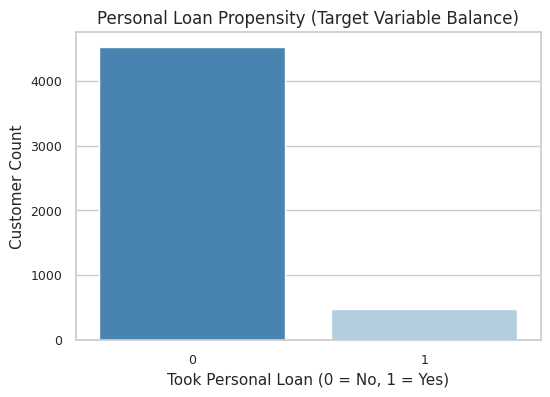

In [ ]:
#TARGET VARIABLE ANALYSIS
target_col = 'Personal Loan'
target_counts = df[target_col].value_counts()
target_pct = df[target_col].value_counts(normalize=True) * 100

print("--- TARGET BASELINE PROPENSITY ---")
print(f"Non-Events (0 - Rejected Loan): {target_counts[0]} customers ({target_pct[0]:.2f}%)")
print(f"Events     (1 - Accepted Loan): {target_counts[1]} customers ({target_pct[1]:.2f}%)")

# Plot distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette="Blues_r")
plt.title("Personal Loan Propensity (Target Variable Balance)")
plt.xlabel("Took Personal Loan (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()

/tmp/ipykernel_18828/326424451.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Personal Loan', y='Income (in K/month)', palette="Set2")


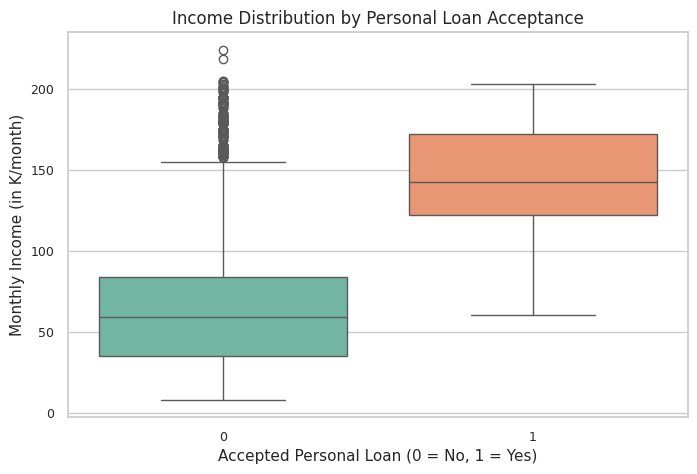

<Figure size 800x500 with 0 Axes>

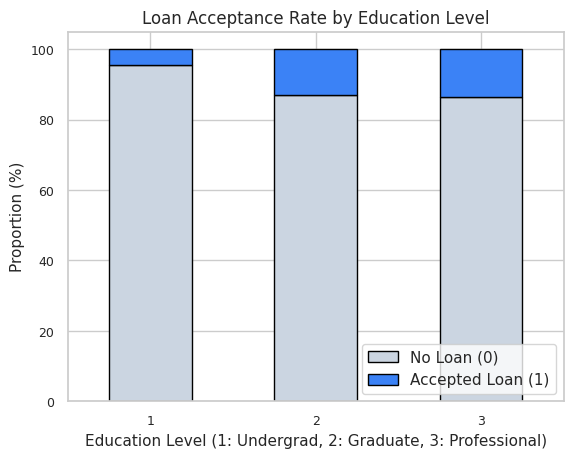

In [ ]:
#BIVARIATE ANALYSIS
# 1. Income distribution across target classes
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Personal Loan', y='Income (in K/month)', palette="Set2")
plt.title("Income Distribution by Personal Loan Acceptance")
plt.xlabel("Accepted Personal Loan (0 = No, 1 = Yes)")
plt.ylabel("Monthly Income (in K/month)")
plt.show()

# 2. Education level impact on target classes
plt.figure(figsize=(8, 5))
edu_cross = pd.crosstab(df['Education'], df['Personal Loan'], normalize='index') * 100
edu_cross.plot(kind='bar', stacked=True, color=['#cbd5e1', '#3b82f6'], edgecolor='black')
plt.title("Loan Acceptance Rate by Education Level")
plt.xlabel("Education Level (1: Undergrad, 2: Graduate, 3: Professional)")
plt.ylabel("Proportion (%)")
plt.legend(["No Loan (0)", "Accepted Loan (1)"], loc="lower right")
plt.xticks(rotation=0)
plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     5000 non-null   int64  
 1   Age (in years)         5000 non-null   int64  
 2   Experience (in years)  5000 non-null   int64  
 3   Income (in K/month)    5000 non-null   int64  
 4   Family members         5000 non-null   object 
 5   CCAvg                  5000 non-null   float64
 6   Education              5000 non-null   int64  
 7   Mortgage               5000 non-null   int64  
 8   Personal Loan          5000 non-null   int64  
 9   Securities Account     5000 non-null   int64  
 10  CD Account             5000 non-null   int64  
 11  Online                 5000 non-null   int64  
 12  CreditCard             5000 non-null   int64  
dtypes: float64(1), int64(11), object(1)
memory usage: 507.9+ KB


In [ ]:
# Drop ID and ZIP Code for correlation calculation
numeric_df = df[numeric_cols]

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("TheraBank Correlation Matrix (Pearson)")
plt.show()

# High correlation checker (r >= 0.75)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) >= 0.75:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            high_corr.append((col_i, col_j, corr_matrix.iloc[i, j]))

if len(high_corr) > 0:
    print("[!] HIGH COLLINEARITY DETECTED (Redundant Variables):")
    for item in high_corr:
         print(f"    - '{item[0]}' & '{item[1]}' (Correlation Coefficient: {item[2]:.2f})")
else:
    print("No critical multicollinearity (r >= 0.75) detected.")


NameError: name 'numeric_cols' is not defined

In [ ]:
import numpy as np

def calculate_woe_iv_table(dataset, feature, target):
    """
    Computes WOE and IV table for a categorical or binned variable.
    """
    ct = pd.crosstab(dataset[feature], dataset[target])
    ct.columns = ['Non_Event', 'Event']

    total_events = ct['Event'].sum()
    total_non_events = ct['Non_Event'].sum()

    ct['Population'] = ct['Event'] + ct['Non_Event']
    ct['Population %'] = ct['Population'] / ct['Population'].sum()


    # Calculate distributions
    ct['Dist_Non_Event'] = ct['Non_Event'] / total_non_events
    ct['Dist_Event'] = ct['Event'] / total_events

    # Soft correction for zero elements to prevent infinity/division-by-zero
    ct['Dist_Non_Event'] = ct['Dist_Non_Event'].replace(0, 0.0001)
    ct['Dist_Event'] = ct['Dist_Event'].replace(0, 0.0001)

    # Calculate Weight of Evidence (WOE)
    ct['WOE'] = np.log(ct['Dist_Non_Event'] / ct['Dist_Event'])

    # Calculate Information Value (IV)
    ct['IV_Contrib'] = (ct['Dist_Non_Event'] - ct['Dist_Event']) * ct['WOE']
    total_iv = ct['IV_Contrib'].sum()

    return ct, total_iv

# List to store results
iv_results = {}
woe_tables = {} # New dictionary to store WOE tables

# Exclude uninformative and target columns from the list
ignore_cols = ['ID', 'Personal Loan', 'ZIP Code']
features_to_rank = [c for c in df.columns if c not in ignore_cols]

for col in features_to_rank:
    # Set up temporary column name for binning
    temp_col = f"{col}_binned"

    # If continuous feature has many unique values, bin them into q bins
    if df[col].dtype in [np.float64, np.int64] and df[col].nunique() > 10:
        try:
            df[temp_col] = pd.qcut(df[col], q=5, duplicates='drop').astype(str)
        except ValueError:
            df[temp_col] = pd.cut(df[col], bins=5).astype(str)
    else:
        # Keep categorical variables/binary flags as strings
        df[temp_col] = df[col].astype(str)

    # Run calculation
    table, iv_val = calculate_woe_iv_table(df, temp_col, 'Personal Loan')
    iv_results[col] = iv_val
    woe_tables[col] = table # Store the WOE table


    # Drop temporary column
    df.drop(columns=[temp_col], inplace=True)

# Format rankings into a table
iv_df = pd.DataFrame(list(iv_results.items()), columns=['Feature', 'Information_Value'])
iv_df = iv_df.sort_values(by='Information_Value', ascending=False).reset_index(drop=True)

# Apply standard scorecard thresholds
def classify_iv(iv):
    if iv < 0.02:   return "Useless (Drop)"
    elif iv < 0.10: return "Weak Predictor"
    elif iv < 0.30: return "Medium Predictor"
    elif iv < 0.50: return "Strong Predictor"
    else:           return "Suspiciously High (Check Overfit)"

iv_df['Predictive_Power'] = iv_df['Information_Value'].apply(classify_iv)

print("--- VARIABLE IMPORTANCE (IV) RANKING TABLE ---")
display(iv_df)

# Display each WOE table with a markdown heading
for feature, woe_table in woe_tables.items():
    print(f"\n--- WOE Table for: {feature} ---")
    display(woe_table)

--- VARIABLE IMPORTANCE (IV) RANKING TABLE ---


,Feature,Information_Value,Predictive_Power
0,Income (in K/month),5.282814,Suspiciously High (Check Overfit)
1,CCAvg,1.607207,Suspiciously High (Check Overfit)
2,CD Account,0.615228,Suspiciously High (Check Overfit)
3,Education,0.299222,Medium Predictor
4,Family members,0.066925,Weak Predictor
5,Mortgage,0.066813,Weak Predictor
6,Securities Account,0.005172,Useless (Drop)
7,Age (in years),0.004800,Useless (Drop)
8,Experience (in years),0.001998,Useless (Drop)
9,Online,0.000456,Useless (Drop)



--- WOE Table for: Age (in years) ---


,Non_Event,Event,Population,Population %,Dist_Non_Event,Dist_Event,WOE,IV_Contrib
Age (in years)_binned,,,,,,,,
"(22.999, 34.0]",1005,118,1123,0.2246,0.222345,0.245833,-0.100423,0.002359
"(34.0, 42.0]",911,88,999,0.1998,0.201549,0.183333,0.094725,0.001725
"(42.0, 50.0]",908,100,1008,0.2016,0.200885,0.208333,-0.036407,0.000271
"(50.0, 57.0]",835,86,921,0.1842,0.184735,0.179167,0.030603,0.000170
"(57.0, 67.0]",861,88,949,0.1898,0.190487,0.183333,0.038277,0.000274



--- WOE Table for: Experience (in years) ---


...

,Non_Event,Event,Population,Population %,Dist_Non_Event,Dist_Event,WOE,IV_Contrib
CD Account_binned,,,,,,,,
0,4358,340,4698,0.9396,0.964159,0.708333,0.308342,0.078882
1,162,140,302,0.0604,0.035841,0.291667,-2.096527,0.536346



--- WOE Table for: Online ---


,Non_Event,Event,Population,Population %,Dist_Non_Event,Dist_Event,WOE,IV_Contrib
Online_binned,,,,,,,,
0,1827,189,2016,0.4032,0.404204,0.39375,0.026202,0.000274
1,2693,291,2984,0.5968,0.595796,0.60625,-0.017393,0.000182



--- WOE Table for: CreditCard ---


,Non_Event,Event,Population,Population %,Dist_Non_Event,Dist_Event,WOE,IV_Contrib
CreditCard_binned,,,,,,,,
0,3193,337,3530,0.706,0.706416,0.702083,0.006152,0.000027
1,1327,143,1470,0.294,0.293584,0.297917,-0.014650,0.000063


To illustrate, let's display the WOE table for 'Income (in K/month)', which was binned into quantiles for the IV calculation.

In [ ]:
temp_income_col = 'Income (in K/month)_binned'
df[temp_income_col] = pd.qcut(df['Income (in K/month)'], q=5, duplicates='drop').astype(str)
income_woe_iv_table, _ = calculate_woe_iv_table(df, temp_income_col, 'Personal Loan')
display(income_woe_iv_table)
# Drop the temporary column after displaying
df.drop(columns=[temp_income_col], inplace=True)

/tmp/ipykernel_18828/167079098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=iv_df, x='Information_Value', y='Feature', palette='viridis')


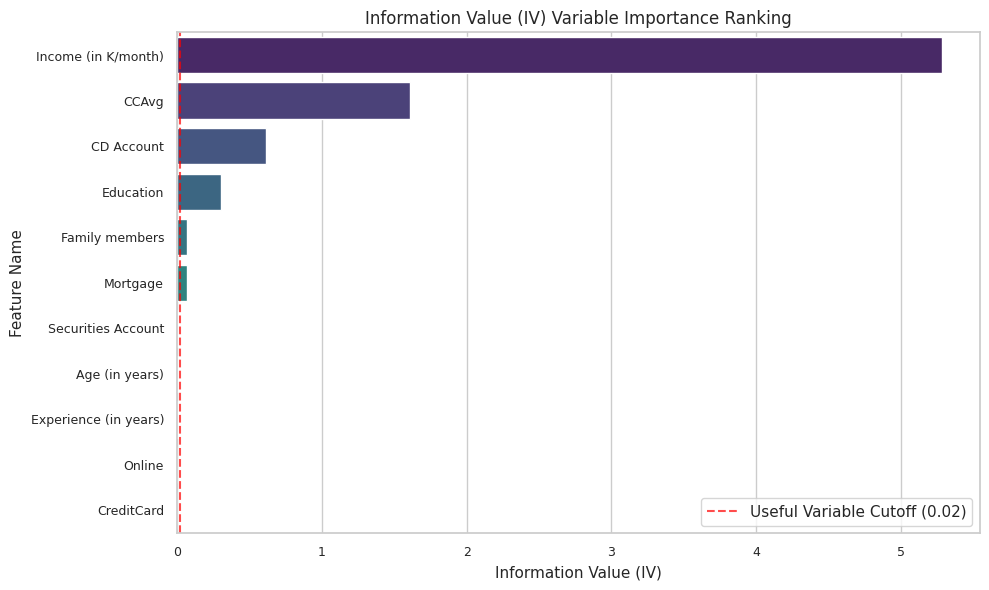

In [ ]:
#VARIABLE IMPORTANCE
plt.figure(figsize=(10, 6))
sns.barplot(data=iv_df, x='Information_Value', y='Feature', palette='viridis')

# Add threshold line for baseline predictive variables (0.02)
plt.axvline(x=0.02, color='red', linestyle='--', alpha=0.7, label='Useful Variable Cutoff (0.02)')
plt.title("Information Value (IV) Variable Importance Ranking")
plt.xlabel("Information Value (IV)")
plt.ylabel("Feature Name")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [ ]:
print([c for c in df.columns if c not in ignore_cols])

['Age (in years)', 'Experience (in years)', 'Income (in K/month)', 'Family members', 'CCAvg', 'Education', 'Mortgage', 'Securities Account', 'CD Account', 'Online', 'CreditCard']


In [ ]:
print(table)

                   Non_Event  Event  Dist_Non_Event  Dist_Event       WOE  \
CreditCard_binned                                                           
0                       3193    337        0.706416    0.702083  0.006152   
1                       1327    143        0.293584    0.297917 -0.014650   

                   IV_Contrib  
CreditCard_binned              
0                    0.000027  
1                    0.000063  


In [ ]:
temp_col

'CreditCard_binned'

In [ ]:
for col in features_to_rank:
  print(table[col])

TypeError: string indices must be integers, not 'str'

In [ ]:
for col in features_to_rank:
  print(woe_table[col])

NameError: name 'woe_table' is not defined

NameError: name 'woe_table' is not defined

In [ ]:
df['Income (in K/month)'].min()

8

In [ ]:
df['Mortgage'].value_counts()

,count
Mortgage,
0,3462
98,17
103,16
89,16
91,16
...,...
550,1
283,1
612,1


## Naive Bayes Classifier Implementation

Naive Bayes is a probabilistic classifier based on Bayes' theorem with the 'naive' assumption of independence between features. It's often simple yet effective, especially in text classification and spam detection. We'll use `GaussianNB` which assumes features follow a Gaussian (normal) distribution.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Redefine numerical and categorical columns for the model, excluding 'ID' and the target variable
numeric_features = ['Age (in years)', 'Experience (in years)', 'Income (in K/month)', 'CCAvg', 'Mortgage']
categorical_features = ['Family members', 'Education', 'Securities Account', 'CD Account', 'Online', 'CreditCard']
target = 'Personal Loan'

# Ensure target column is int for classification
df[target] = df[target].astype(int)

# Separate features (X) and target (y)
X = df[numeric_features + categorical_features]
y = df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

In [ ]:
# Create preprocessing pipelines for numerical and categorical features
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create the Naive Bayes model pipeline
# The preprocessor will transform the data, and then GaussianNB will be applied
nb_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', GaussianNB())])

# Train the Naive Bayes model
nb_model.fit(X_train, y_train)

print("Naive Bayes model training complete!")

In [ ]:
# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

print(f"\n--- Naive Bayes Model Evaluation ---")
print(f"Accuracy: {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall: {recall_nb:.4f}")
print(f"F1-Score: {f1_nb:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_nb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()